In [ ]:
import re
import pandas as pd
from langfuse import Langfuse
import matplotlib.pyplot as plt

from polylex_chatbot.env import load_project_env

env_path = load_project_env()

In [ ]:
langfuse = Langfuse()
DATASET_NAME = "20250520_clean_dev_dataset"
dataset = langfuse.get_dataset(DATASET_NAME)
RUN_NAME = "2026-06-17T10:09:54.982964"

In [3]:
run = langfuse.get_dataset_run(
    dataset_name=DATASET_NAME,
    run_name=RUN_NAME
)
trace_ids = [item.trace_id for item in run.dataset_run_items]
results = [langfuse.api.trace.get(trace_id).scores for trace_id in trace_ids]

In [4]:
def langfuse_scores_to_df(results):
    rows = []

    for result in results:
        for metric in result:
            rows.append({
                "trace_id": metric.observation_id,
                "metric": metric.name,
                "value": metric.value
            })

    df_long = pd.DataFrame(rows)

    df_wide = (
        df_long
        .pivot_table(
            index=["trace_id"],
            columns="metric",
            values="value",
            aggfunc="first"
        )
        .reset_index()
    )

    df_wide.columns.name = None

    return df_wide

In [5]:
df_scores = langfuse_scores_to_df(results)
df_scores

,trace_id,hit_at_1,hit_at_10,hit_at_15,hit_at_2,hit_at_20,hit_at_3,hit_at_4,hit_at_5,mrr_doc,nb_correct_doc
0,131757411817ebb3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,4.0
1,315e41685e0db31d,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,5.0
2,58017e0656a81d23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,70435902d095c9d1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,6.0
4,863e3cfdc7fb9daa,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,2.0
5,91bbcb3573726519,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
6,ad087f122ce651e0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,5.0
7,aed4fd879c89d36e,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.250000,1.0
8,c27de416781cff85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
9,c9595c2b85622746,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,4.0


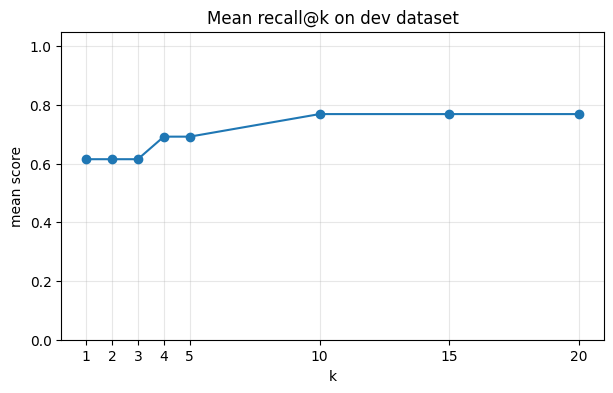

In [6]:
recall_cols = [col for col in df_scores.columns if re.match(r"^hit_at_\d+$", col)]

recall_df = pd.DataFrame({
    "k": [int(col.split("_")[-1]) for col in recall_cols],
    "mean_recall": [df_scores[col].mean() for col in recall_cols],
}).sort_values("k")

plt.figure(figsize=(7, 4))
plt.plot(
    recall_df["k"],
    recall_df["mean_recall"],
    marker="o",
)

plt.xlabel("k")
plt.ylabel("mean score")
plt.title("Mean recall@k on dev dataset")
plt.xticks(recall_df["k"])
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()